# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Reza Maulana
- **Email:** cdcc299d6y2532@student.devacademy.id
- **ID Dicoding:** CDCC299D6Y2532

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Berapa total pendapatan penjualan (revenue) yang dihasilkan setiap bulan dalam rentang waktu tahun 2018 dalam melihat pola musim penjualan?
- **Pertanyaan 2:** Kategori produk apa yang memiliki rata-rata skor di bawah 4.0 pada tahun 2017 sebagai identifikasi produk yang perlu ditingkatkan kualitasnya?
- ...

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
# Dataset untuk pertanyaan 1
orders_df = pd.read_csv(r'C:\Users\abang\Documents\Submission Dicoding\orders_dataset.csv')
order_payments_df = pd.read_csv(r'C:\Users\abang\Documents\Submission Dicoding\order_payments_dataset.csv')

# Dataset untuk pertanyaan 2
order_items_df = pd.read_csv(r'C:\Users\abang\Documents\Submission Dicoding\order_items_dataset.csv')
order_reviews_df = pd.read_csv(r'C:\Users\abang\Documents\Submission Dicoding\order_reviews_dataset.csv')
products_df = pd.read_csv(r'C:\Users\abang\Documents\Submission Dicoding\products_dataset.csv')
category_trans_df = pd.read_csv(r'C:\Users\abang\Documents\Submission Dicoding\product_category_name_translation.csv')

# Dibuat dictionary agar memudahkan ketika memanggil dataframenya
datasets = {
    'orders' : orders_df,
    'order_payments' : order_payments_df,
    'order_items' : order_items_df,
    'order_reviews' : order_reviews_df,
    'products' : products_df,
    'category_trans' : category_trans_df
}

**Insight:** (Opsional)
- Saya menggunakan beberapa datasets dalam memenuhi kebutuhan untuk menjawab Business Question yang telah saya buat sebelumnya
- Saya memasukkan beberapa datasets ke dalam dictionary tujuannya agar memudahkan saya ketika ingin memanggil beberapa datasets

In [3]:
# Digunakan untuk menampilkan 3 rows teratas pada setiap dataset
print('=== ORDERS ===')
display(orders_df.head(3))

print('=== ORDER PAYMENTS ===')
display(order_payments_df.head(3))

print('=== ORDER ITEMS ===')
display(order_items_df.head(3))

print('=== ORDER REVIEWS ===')
display(order_reviews_df.head(3))

print('=== PRODUCTS ===')
display(products_df.head(3))

print('=== CATEGORY TRANSLATION ===')
display(category_trans_df.head(3))

=== ORDERS ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


=== ORDER PAYMENTS ===


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


=== ORDER ITEMS ===


...

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


=== PRODUCTS ===


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


=== CATEGORY TRANSLATION ===


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


### Assessing Data

#### Identifying Missing Value problem

In [4]:
# 1. Missing Value
for name, df in datasets.items():
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f'Dataset: {name} → Missing Value: {missing}')
    else:
        print(f'Dataset: {name} → Missing Value: Tidak ada')

Dataset: orders → Missing Value: order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
Dataset: order_payments → Missing Value: Tidak ada
Dataset: order_items → Missing Value: Tidak ada
Dataset: order_reviews → Missing Value: review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64
Dataset: products → Missing Value: product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm           

#### Identifying Duplicate Data problem

In [5]:
# 2. Duplicate Data
for name, df in datasets.items():
    duplicate = df.duplicated().sum()
    if duplicate > 0:
        print(f'Dataset: {name} → Duplicate Data: {duplicate}')
    else:
        print(f'Dataset: {name} → Duplicate Data Tidak Ada')

Dataset: orders → Duplicate Data Tidak Ada
Dataset: order_payments → Duplicate Data Tidak Ada
Dataset: order_items → Duplicate Data Tidak Ada
Dataset: order_reviews → Duplicate Data Tidak Ada
Dataset: products → Duplicate Data Tidak Ada
Dataset: category_trans → Duplicate Data Tidak Ada


#### Identifying Inaccurate Value problem

In [6]:
# 3. Inaccurate Value (Ketidaktepatan Tipe Data)
for name, df in datasets.items():
    print(f'\n=== {name} ===')
    print(df.dtypes.to_frame(name='Tipe Data'))


=== orders ===
                              Tipe Data
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object

=== order_payments ===
                     Tipe Data
order_id                object
payment_sequential       int64
payment_type            object
payment_installments     int64
payment_value          float64

=== order_items ===
                    Tipe Data
order_id               object
order_item_id           int64
product_id             object
seller_id              object
shipping_limit_date    object
price                 float64
freight_value         float64

=== order_reviews ===
                        Tipe Data
review_id                  object
order_id                   object
review_score                

**Steps to Take:**
- Missing value pada `order_approved_at` (160 baris), `order_delivered_carrier_date` (1.783 baris), dan `order_delivered_customer_date` (2.965 baris) bukan error data hal ini dapat dikatakan wajar karena ada order yang statusnya bukan delivered (misal: cancelled, shipped, processing) dan kemudian nantinya akan difilter hanya dengan status order `delivered`.
- Missing value pada `review_comment_title` (87.656 baris) dan `review_comment_message` (58.247 baris) bersifat opsional karena pelanggan tidak diwajibkan mengisi komentar. Kolom ini tidak digunakan dalam analisis sehingga boleh saja jika diabaikan.
- Missing value pada `product_category_name` (610 baris) perlu diisi dengan nilai `'unknown'` agar baris tidak hilang saat proses merge antar dataset
- Missing value pada kolom dimensi produk seperti `product_name_lenght`, `product_description_lenght`, `product_photos_qty` (masing-masing 610 baris) dan `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm` (masing-masing 2 baris) akan diisi menggunakan nilai **median** karena jumlahnya kecil dan tidak signifikan.
- Tidak ditemukan duplicate data pada seluruh dataset sehingga tidak diperlukan penanganan lebih lanjut.
- Seluruh kolom bertipe tanggal pada `orders_df`, `order_items_df`, dan `order_reviews_df` masih bertipe `object` sehingga perlu dikonversi ke `datetime64` menggunakan `pd.to_datetime()`.

**Insight:** (Opsional)
- Dataset yang paling banyak missing value adalah `products_df` dengan 610 baris produk tanpa kategori, kemungkinan besar merupakan produk yang belum selesai dikonfigurasi oleh seller.
- Tidak ada duplikat di seluruh dataset yang digunakan, sehingga kualitas data dari sisi keunikan baris sudah cukup baik.

### Cleaning Data

#### Fixing Inaccurate Value problem

In [7]:
# Mengubah tipe data yang kurang benar yaitu datetime pada orders_df
datetime_cols_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols_orders:
    orders_df[col] = pd.to_datetime(orders_df[col])

orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [8]:
# Mengubah tipe data yang kurang benar yaitu datetime pada order_items_df
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [9]:
# Mengubah tipe data yang kurang benar yaitu datetime pada order_reviews_df
datetime_cols_reviews = [
    'review_creation_date',
    'review_answer_timestamp'
]
for col in datetime_cols_reviews:
    order_reviews_df[col] = pd.to_datetime(order_reviews_df[col])

order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


#### Fixing Missing Value problem

In [10]:
# 1. Mengisi missing value pada product_df kolom product_category_name dengan 'unknown'
products_df = products_df.copy() # Menggunakan copy agar data sebelumnya dapat aman ketika ingin digunakan kembali
products_df ['product_category_name'] = products_df ['product_category_name'].fillna('unknown')
print('Missing product_category_name diisi "unknown"')
print(f'Sisa missing: {products_df["product_category_name"].isnull().sum()}')

Missing product_category_name diisi "unknown"
Sisa missing: 0


In [11]:
# 2. Mengisi missing value kolom dimensi serta deskripsi produk dengan median
cols_median = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]
for col in cols_median:
    products_df[col] = products_df[col].fillna(products_df[col].median())

print('Missing value kolom dimensi produk telah diisi dengan median')
print('Sisa missing value di products_df:')
print(products_df.isnull().sum())

Missing value kolom dimensi produk telah diisi dengan median
Sisa missing value di products_df:
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


In [12]:
# 3. Melakukan filtering data hanya pada status delivered dan menambahkan kolom turunan agar tidak terjadi missing value
orders_clean = orders_df[orders_df['order_status'] == 'delivered'].copy()
orders_clean['order_year']       = orders_clean['order_purchase_timestamp'].dt.year
orders_clean['order_month']      = orders_clean['order_purchase_timestamp'].dt.month
orders_clean['order_month_name'] = orders_clean['order_purchase_timestamp'].dt.strftime('%b')

print(f'\n✅ Filter status delivered selesai')
print(f'   Total order delivered: {len(orders_clean):,} baris')


✅ Filter status delivered selesai
   Total order delivered: 96,478 baris


**Insight:** (Opsional)
- Setelah filtering status `delivered`, jumlah baris orders berkurang dari 99.441 menjadi sekitar 96.478 baris yang artinya sekitar 3% order tidak sampai ke tahap delivered
- Seluruh missing value yang relevan untuk analisis sudah berhasil ditangani sehingga data siap digunakan pada tahap EDA

## Exploratory Data Analysis (EDA)

### Explore Revenue Bulanan Tahun 2018 Untuk Pertanyaan 1

In [13]:
# Melakukan agregasi payment per order
payment_agg = (
    order_payments_df
    .groupby('order_id')['payment_value']
    .sum()
    .reset_index()
)

In [14]:
# Menggabungkan orders 2018 dengan payment
orders_2018 = orders_clean[orders_clean['order_year'] == 2018]
df_q1 = orders_2018.merge(payment_agg, on='order_id', how='left')

In [15]:
# Menghitung revenue per bulannya
monthly_rev = (
    df_q1
    .groupby(['order_month', 'order_month_name'])['payment_value']
    .sum()
    .reset_index()
    .sort_values('order_month')
    .reset_index(drop=True)
)

total = monthly_rev['payment_value'].sum()
max_row = monthly_rev.loc[monthly_rev['payment_value'].idxmax()]
min_row = monthly_rev.loc[monthly_rev['payment_value'].idxmin()]

In [16]:
# Menampilkan hasil perhitungan
print('=== REVENUE BULANAN TAHUN 2018 ===')
print(f"{'Bulan':<8} {'Total Revenue':>18} {'% dari Total':>14}")
print('-' * 44)
for _, row in monthly_rev.iterrows():
    pct = row['payment_value'] / total * 100
    print(f"{row['order_month_name']:<8} R$ {row['payment_value']:>14,.2f}   {pct:>6.1f}%")
print('-' * 44)
print(f"{'TOTAL':<8} R$ {total:>14,.2f}   100.0%")
print(f"\n📈 Bulan tertinggi : {max_row['order_month_name']} (R$ {max_row['payment_value']:,.2f})")
print(f"📉 Bulan terendah  : {min_row['order_month_name']} (R$ {min_row['payment_value']:,.2f})")
print(f"📊 Rata-rata/bulan : R$ {monthly_rev['payment_value'].mean():,.2f}")

=== REVENUE BULANAN TAHUN 2018 ===
Bulan         Total Revenue   % dari Total
--------------------------------------------
Jan      R$   1,078,606.86     12.8%
Feb      R$     966,510.88     11.4%
Mar      R$   1,120,678.00     13.3%
Apr      R$   1,132,933.95     13.4%
May      R$   1,128,836.69     13.4%
Jun      R$   1,012,090.68     12.0%
Jul      R$   1,027,903.86     12.2%
Aug      R$     985,414.28     11.7%
--------------------------------------------
TOTAL    R$   8,452,975.20   100.0%

📈 Bulan tertinggi : Apr (R$ 1,132,933.95)
📉 Bulan terendah  : Feb (R$ 966,510.88)
📊 Rata-rata/bulan : R$ 1,056,621.90


**Insight:** (Opsional)
- Revenue tertinggi terjadi pada bulan April 2018 `(R$ 1,132,933.95)`
- Revenue terendah terjadi pada bulan Februari 2018 `(R$ 966,510.88)`
- Data tahun 2018 hanya mencakup bulan Januari hingga Agustus saja, sehingga tidak bisa melihat pola musiman secara penuh sepanjang tahun
- Secara umum revenue cukup stabil di rentang `(R$966rb – R$1,13jt)` per bulan tanpa fluktuasi yang terlalu ekstrem, dengan tren sedikit naik di Maret-April kemudian turun bertahap mulai Juni hingga Agustus

### Explore Kategori Produk dengan Review Score Rendah Pada Tahun 2017 Untuk Pertanyaan 2

In [17]:
# Mengambil order pada tahun 2017
orders_2017 = orders_clean[orders_clean['order_year'] == 2017][['order_id']]

In [18]:
# Melakukan agregasi review score per order (menggunakan median jika terdapat lebih dari 1 review)
reviews_per_order = (
    order_reviews_df
    .groupby('order_id')['review_score']
    .median()
    .reset_index()
)

In [19]:
# Menggabungkan orders 2017, order_items, products, category_trans, reviews
df_q2 = (
    orders_2017
    .merge(order_items_df[['order_id', 'product_id']], on='order_id', how='left')
    .merge(products_df[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(category_trans_df, on='product_category_name', how='left')
    .merge(reviews_per_order, on='order_id', how='left')
    .dropna(subset=['review_score', 'product_category_name_english'])
)

In [20]:
# Menghitung rata-rata score per kategori
category_score = (
    df_q2
    .groupby('product_category_name_english')
    .agg(
        avg_score = ('review_score', 'mean'),
        total_orders = ('order_id', 'count')
    )
    .reset_index()
)

In [21]:
# Melakukan filtering dengan minimal 10 order saja supaya data menjadi representif
category_score = category_score[category_score['total_orders'] >= 10]

In [22]:
# Memfilter kategori dengan rata-rata score < 4.0
category_low = (
    category_score[category_score['avg_score'] < 4.0]
    .sort_values('avg_score')
    .reset_index(drop=True)
)

In [23]:
print('=== KATEGORI DENGAN AVG REVIEW SCORE < 4.0 TAHUN 2017 ===')
print(f'Total kategori dievaluasi (min 10 order): {len(category_score)}')
print(f'Kategori perlu perhatian (score < 4.0)  : {len(category_low)}')
print(f"\n{'#':<4} {'Kategori':<40} {'Avg Score':>10} {'Total Order':>12}")
print('-' * 70)
for i, row in category_low.iterrows():
    print(f"{i+1:<4} {row['product_category_name_english']:<40} "
          f"{row['avg_score']:>10.3f} {int(row['total_orders']):>12,}")

=== KATEGORI DENGAN AVG REVIEW SCORE < 4.0 TAHUN 2017 ===
Total kategori dievaluasi (min 10 order): 63
Kategori perlu perhatian (score < 4.0)  : 13

#    Kategori                                  Avg Score  Total Order
----------------------------------------------------------------------
1    office_furniture                              3.574          785
2    construction_tools_lights                     3.611           18
3    fashion_male_clothing                         3.612           98
4    agro_industry_and_commerce                    3.721           61
5    construction_tools_safety                     3.775           40
6    fashio_female_clothing                        3.786           28
7    audio                                         3.794          163
8    home_confort                                  3.835          273
9    fixed_telephony                               3.844          147
10   home_construction                             3.878          139
11   bed_b

**Insight:** (Opsional)
- Terdapat 13 kategori produk yang memiliki rata-rata review score di bawah 4.0 pada tahun 2017
- Kategori `office_furniture` menjadi yang paling kritis karena memiliki score terendah (3.57) sekaligus volume order tertinggi di antara kategori bermasalah lainnya (785 order), sehingga dampaknya paling besar terhadap kepuasan pelanggan

## Visualization & Explanatory Analysis

### Pertanyaan 1: Berapa total pendapatan penjualan (revenue) yang dihasilkan setiap bulan dalam rentang waktu tahun 2018 dalam melihat pola musim penjualan?

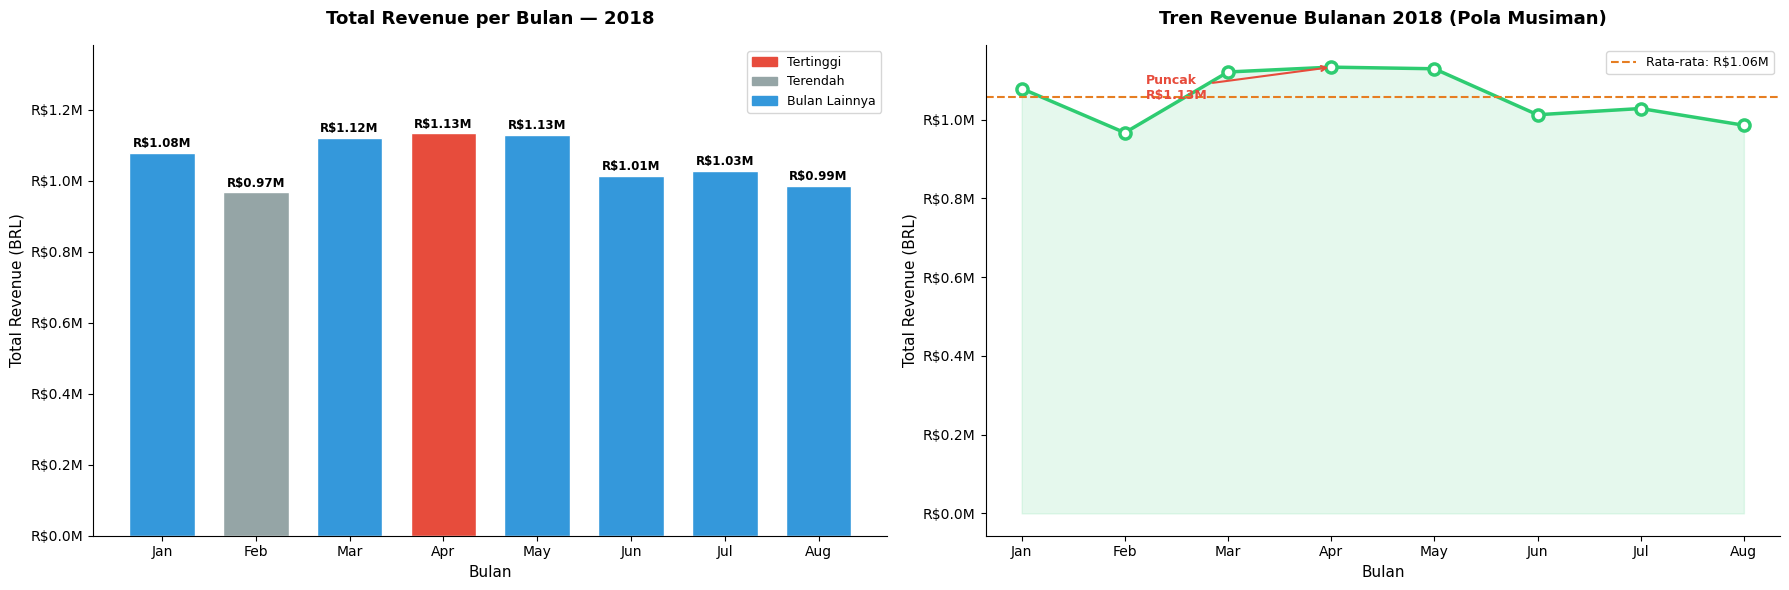

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

labels = monthly_rev['order_month_name'].tolist()
values = monthly_rev['payment_value'].tolist()
max_i  = monthly_rev['payment_value'].idxmax()
min_i  = monthly_rev['payment_value'].idxmin()

bar_colors = [
    '#e74c3c' if i == max_i else
    '#95a5a6' if i == min_i else
    '#3498db'
    for i in range(len(labels))
]

# --- Bar chart ---
bars = axes[0].bar(labels, values, color=bar_colors, edgecolor='white', width=0.7)
for bar, val in zip(bars, values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8000,
        f'R${val/1e6:.2f}M',
        ha='center', va='bottom', fontsize=8.5, fontweight='bold'
    )
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
axes[0].set_ylim(0, max(values) * 1.22)
axes[0].set_title('Total Revenue per Bulan — 2018', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Bulan', fontsize=11)
axes[0].set_ylabel('Total Revenue (BRL)', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
legend_el = [
    mpatches.Patch(color='#e74c3c', label=f'Tertinggi'),
    mpatches.Patch(color='#95a5a6', label=f'Terendah'),
    mpatches.Patch(color='#3498db', label='Bulan Lainnya'),
]
axes[0].legend(handles=legend_el, fontsize=9)

# --- Line chart tren ---
axes[1].plot(
    range(len(labels)), values,
    color='#2ecc71', linewidth=2.5,
    marker='o', markersize=8,
    markerfacecolor='white', markeredgewidth=2.5
)
axes[1].fill_between(range(len(labels)), values, alpha=0.12, color='#2ecc71')
axes[1].axhline(
    y=np.mean(values), color='#e67e22',
    linestyle='--', linewidth=1.5,
    label=f"Rata-rata: R${np.mean(values)/1e6:.2f}M"
)
axes[1].annotate(
    f'Puncak\nR${values[max_i]/1e6:.2f}M',
    xy=(max_i, values[max_i]),
    xytext=(max_i - 1.8, values[max_i] - 80000),
    fontsize=9, color='#e74c3c', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5)
)
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
axes[1].set_title('Tren Revenue Bulanan 2018 (Pola Musiman)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Bulan', fontsize=11)
axes[1].set_ylabel('Total Revenue (BRL)', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Pertanyaan 2: Kategori produk apa yang memiliki rata-rata skor di bawah 4.0 pada tahun 2017 sebagai identifikasi produk yang perlu ditingkatkan kualitasnya?

C:\Users\abang\AppData\Local\Temp\ipykernel_16992\3711972569.py:66: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\abang\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


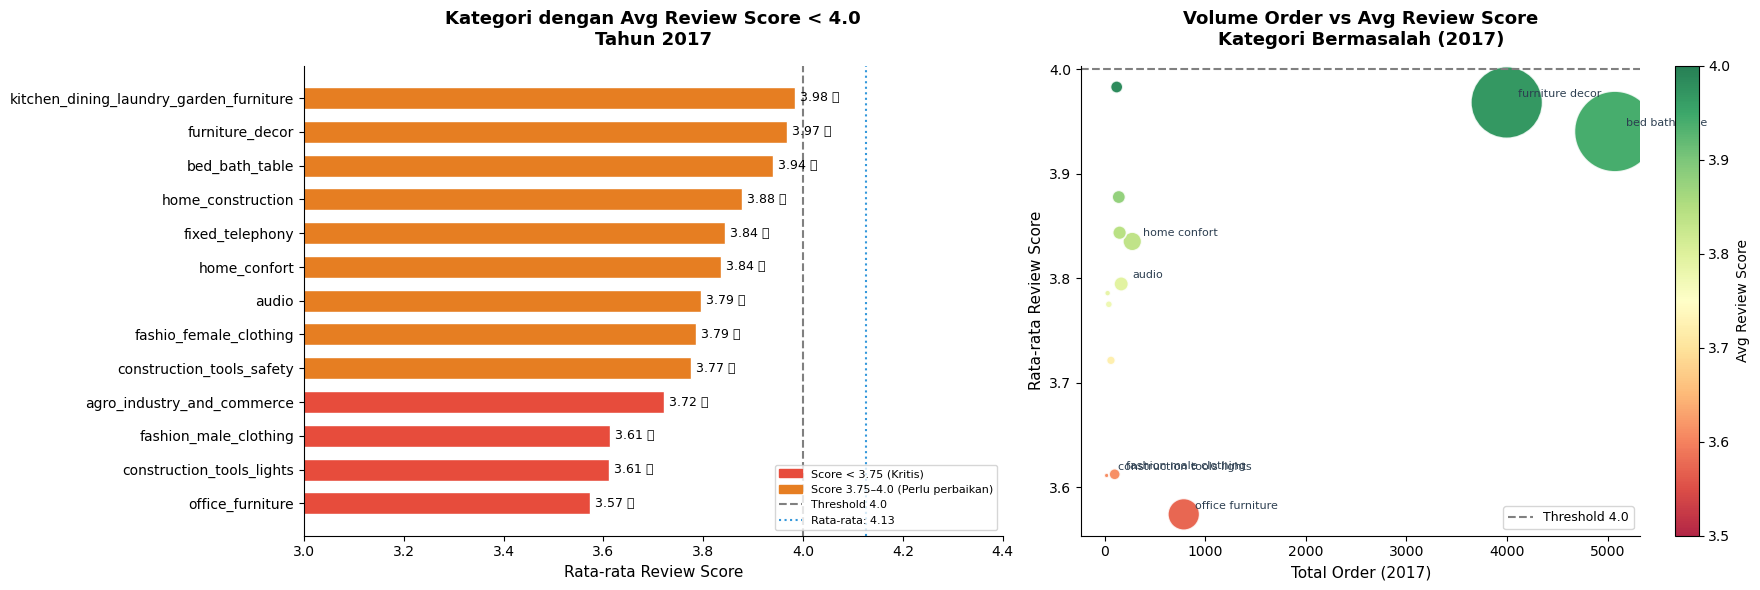

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

bar_colors2 = [
    '#e74c3c' if s < 3.75 else '#e67e22'
    for s in category_low['avg_score']
]

# --- Horizontal bar chart ---
bars2 = axes[0].barh(
    category_low['product_category_name_english'],
    category_low['avg_score'],
    color=bar_colors2, edgecolor='white', height=0.65
)
for bar, val in zip(bars2, category_low['avg_score']):
    axes[0].text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f} ⭐',
        va='center', ha='left', fontsize=9
    )
axes[0].axvline(x=4.0, color='gray', linestyle='--', linewidth=1.5, label='Threshold 4.0')
axes[0].axvline(
    x=category_score['avg_score'].mean(), color='#3498db',
    linestyle=':', linewidth=1.5,
    label=f"Rata-rata semua kategori: {category_score['avg_score'].mean():.2f}"
)
axes[0].set_xlim(3.0, 4.4)
axes[0].set_title('Kategori dengan Avg Review Score < 4.0\nTahun 2017', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Rata-rata Review Score', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
legend_el2 = [
    mpatches.Patch(color='#e74c3c', label='Score < 3.75 (Kritis)'),
    mpatches.Patch(color='#e67e22', label='Score 3.75–4.0 (Perlu perbaikan)'),
    plt.Line2D([0],[0], color='gray', linestyle='--', label='Threshold 4.0'),
    plt.Line2D([0],[0], color='#3498db', linestyle=':', label=f"Rata-rata: {category_score['avg_score'].mean():.2f}"),
]
axes[0].legend(handles=legend_el2, fontsize=8, loc='lower right')

# --- Bubble chart: score vs volume order ---
scatter = axes[1].scatter(
    category_low['total_orders'],
    category_low['avg_score'],
    s=category_low['total_orders'] / 1.5,
    c=category_low['avg_score'],
    cmap='RdYlGn', vmin=3.5, vmax=4.0,
    alpha=0.85, edgecolors='white', linewidth=1.2
)
for _, row in category_low.iterrows():
    if row['total_orders'] > 150 or row['avg_score'] < 3.7:
        axes[1].annotate(
            row['product_category_name_english'].replace('_', ' '),
            xy=(row['total_orders'], row['avg_score']),
            xytext=(8, 4), textcoords='offset points',
            fontsize=8, color='#2c3e50'
        )
axes[1].axhline(y=4.0, color='gray', linestyle='--', linewidth=1.5, label='Threshold 4.0')
plt.colorbar(scatter, ax=axes[1], label='Avg Review Score')
axes[1].set_title('Volume Order vs Avg Review Score\nKategori Bermasalah (2017)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Total Order (2017)', fontsize=11)
axes[1].set_ylabel('Rata-rata Review Score', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Visualisasi bar chart pada pertanyaan 1 menunjukkan bahwa April 2018 merupakan puncak revenue dengan lonjakan yang cukup signifikan dibandingkan bulan lainnya, sementara tren keseluruhan menunjukkan pola naik di awal tahun dan turun di pertengahan hingga akhir tahun
- Pada pertanyaan 2, bubble chart memperlihatkan bahwa kategori `office_furniture` adalah yang paling mengkhawatirkan karena menggabungkan dua faktor risiko sekaligus: rating terendah dan volume order tertinggi di antara semua kategori bermasalah

## Analisis Lanjutan (Opsional)

### 1. Perbandingan Revenue Bulanan Tahun 2017 vs 2018

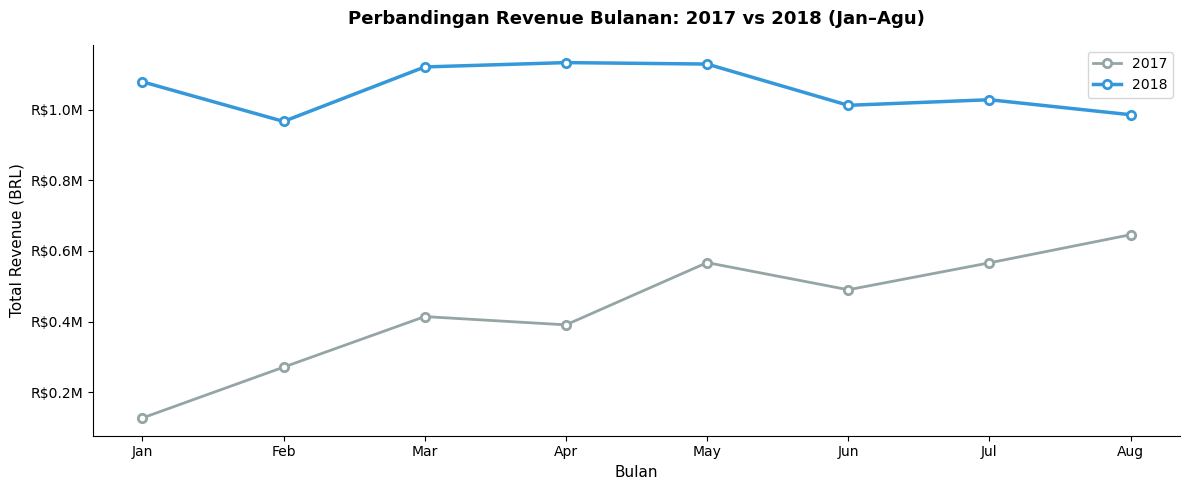

In [27]:
orders_2017_rev = orders_clean[orders_clean['order_year'] == 2017]
df_2017_rev = orders_2017_rev.merge(payment_agg, on='order_id', how='left')

monthly_2017 = (
    df_2017_rev
    .groupby(['order_month', 'order_month_name'])['payment_value']
    .sum().reset_index().sort_values('order_month')
)
monthly_2018 = monthly_rev.copy()

# Bulan yang sama di kedua tahun (1-8)
common_months = range(1, 9)
rev_2017 = monthly_2017[monthly_2017['order_month'].isin(common_months)]
rev_2018 = monthly_2018[monthly_2018['order_month'].isin(common_months)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(rev_2017)), rev_2017['payment_value'],
        color='#95a5a6', linewidth=2, marker='o', markersize=6,
        markerfacecolor='white', markeredgewidth=2, label='2017')
ax.plot(range(len(rev_2018)), rev_2018['payment_value'],
        color='#3498db', linewidth=2.5, marker='o', markersize=6,
        markerfacecolor='white', markeredgewidth=2, label='2018')

ax.set_xticks(range(len(rev_2017)))
ax.set_xticklabels(rev_2017['order_month_name'].tolist())
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.set_title('Perbandingan Revenue Bulanan: 2017 vs 2018 (Jan–Agu)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Bulan', fontsize=11)
ax.set_ylabel('Total Revenue (BRL)', fontsize=11)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 2. RFM Analysis

RFM Analysis digunakan untuk mengelompokkan pelanggan berdasarkan perilaku pembelian mereka:
- **Recency (R):** Berapa hari sejak terakhir kali pelanggan melakukan pembelian
- **Frequency (F):** Berapa kali pelanggan melakukan transaksi
- **Monetary (M):** Berapa total pengeluaran pelanggan

Dataset yang digunakan: `orders_clean` + `order_payments_df`

In [29]:
# Agregasi payment per order
payment_agg_rfm = (
    order_payments_df
    .groupby('order_id')['payment_value']
    .sum()
    .reset_index()
)

# Gabungkan orders dengan payment
df_rfm = orders_clean.merge(payment_agg_rfm, on='order_id', how='left')

# Hitung RFM per customer
snapshot_date = df_rfm['order_purchase_timestamp'].dt.date.max()

rfm_df = (
    df_rfm.groupby('customer_id')
    .agg(
        last_order    = ('order_purchase_timestamp', 'max'),
        frequency     = ('order_id', 'nunique'),
        monetary      = ('payment_value', 'sum')
    )
    .reset_index()
)

rfm_df['recency'] = rfm_df['last_order'].apply(lambda x: (snapshot_date - x.date()).days)
rfm_df = rfm_df.drop(columns='last_order')

print(f'Snapshot date  : {snapshot_date}')
print(f'Total customers: {len(rfm_df):,}')
print()
print(rfm_df[['recency', 'frequency', 'monetary']].describe().round(2))

Snapshot date  : 2018-08-29
Total customers: 96,478

        recency  frequency  monetary
count  96478.00    96478.0  96478.00
mean     239.66        1.0    159.85
std      152.84        0.0    218.81
min        0.00        1.0      0.00
25%      116.00        1.0     61.88
50%      221.00        1.0    105.28
75%      349.00        1.0    176.33
max      713.00        1.0  13664.08


In [30]:
# Scoring RFM menggunakan binning (quintile 1-5)
# Recency: semakin kecil nilainya semakin bagus → skor dibalik
rfm_df['R_score'] = pd.qcut(rfm_df['recency'],  q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm_df['F_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm_df['M_score'] = pd.qcut(rfm_df['monetary'],  q=5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm_df['RFM_score'] = rfm_df['R_score'] + rfm_df['F_score'] + rfm_df['M_score']

print('Distribusi RFM Score:')
print(rfm_df['RFM_score'].value_counts().sort_index())

Distribusi RFM Score:
RFM_score
3       788
4      2284
5      4771
6      7837
7     11547
8     13677
9     14600
10    13650
11    11590
12     7859
13     4710
14     2368
15      797
Name: count, dtype: int64


In [31]:
# Segmentasi pelanggan berdasarkan RFM Score (Manual Grouping)
def segment_customer(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalist'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm_df['segment'] = rfm_df['RFM_score'].apply(segment_customer)

segment_summary = (
    rfm_df.groupby('segment')
    .agg(
        jumlah_customer = ('customer_id', 'count'),
        avg_recency     = ('recency', 'mean'),
        avg_frequency   = ('frequency', 'mean'),
        avg_monetary    = ('monetary', 'mean')
    )
    .round(2)
    .reset_index()
    .sort_values('jumlah_customer', ascending=False)
)

print('=== SEGMENTASI PELANGGAN BERDASARKAN RFM ===')
print(segment_summary.to_string(index=False))

=== SEGMENTASI PELANGGAN BERDASARKAN RFM ===
           segment  jumlah_customer  avg_recency  avg_frequency  avg_monetary
Potential Loyalist            39824       269.50            1.0        127.04
   Loyal Customers            33099       176.07            1.0        208.85
           At Risk            12608       356.89            1.0         67.78
         Champions             7875        90.73            1.0        311.44
    Lost Customers             3072       438.46            1.0         46.64


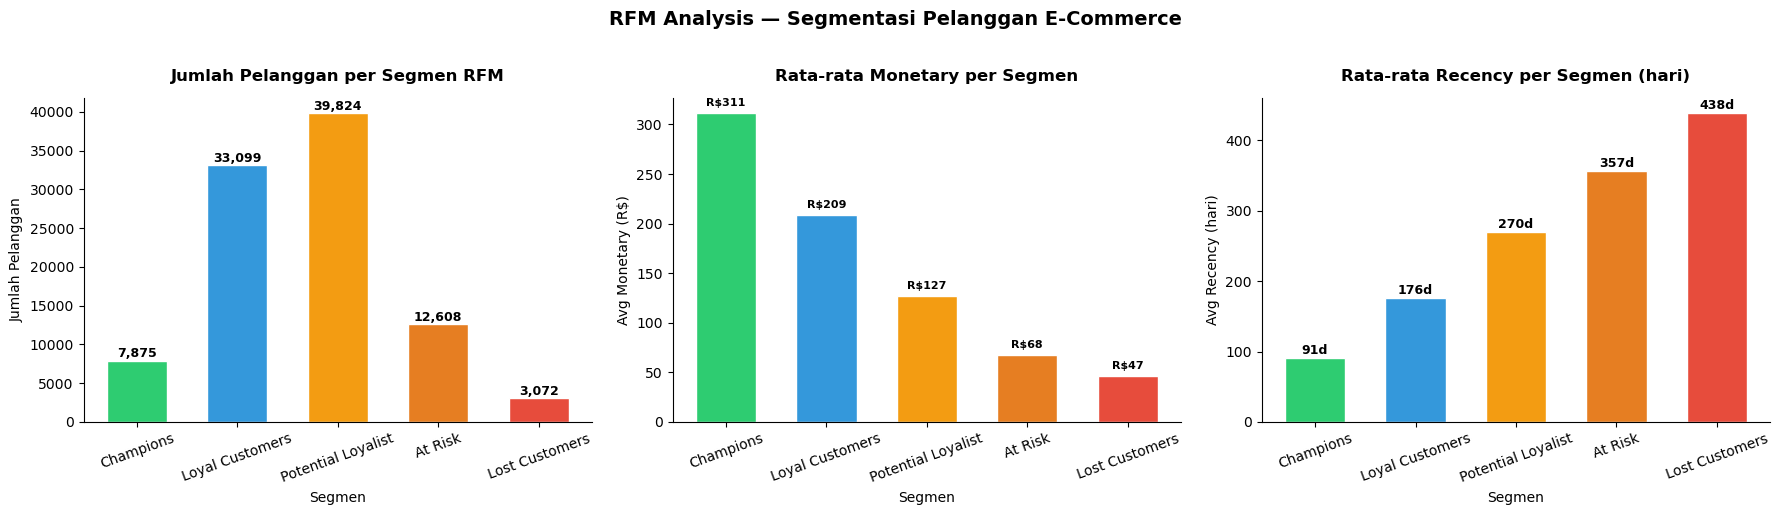

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

segment_order = ['Champions', 'Loyal Customers', 'Potential Loyalist', 'At Risk', 'Lost Customers']
colors_seg    = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']

seg_count = rfm_df['segment'].value_counts().reindex(segment_order).fillna(0)

# --- Bar: Jumlah Pelanggan per Segmen ---
bars = axes[0].bar(segment_order, seg_count.values, color=colors_seg, edgecolor='white', width=0.6)
for bar, val in zip(bars, seg_count.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{int(val):,}', ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
axes[0].set_title('Jumlah Pelanggan per Segmen RFM', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Segmen', fontsize=10)
axes[0].set_ylabel('Jumlah Pelanggan', fontsize=10)
axes[0].tick_params(axis='x', rotation=20)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Bar: Avg Monetary per Segmen ---
avg_mon = rfm_df.groupby('segment')['monetary'].mean().reindex(segment_order)
bars2   = axes[1].bar(segment_order, avg_mon.values, color=colors_seg, edgecolor='white', width=0.6)
for bar, val in zip(bars2, avg_mon.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'R${val:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold'
    )
axes[1].set_title('Rata-rata Monetary per Segmen', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Segmen', fontsize=10)
axes[1].set_ylabel('Avg Monetary (R$)', fontsize=10)
axes[1].tick_params(axis='x', rotation=20)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# --- Bar: Avg Recency per Segmen ---
avg_rec = rfm_df.groupby('segment')['recency'].mean().reindex(segment_order)
bars3   = axes[2].bar(segment_order, avg_rec.values, color=colors_seg, edgecolor='white', width=0.6)
for bar, val in zip(bars3, avg_rec.values):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{val:.0f}d', ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
axes[2].set_title('Rata-rata Recency per Segmen (hari)', fontsize=12, fontweight='bold', pad=12)
axes[2].set_xlabel('Segmen', fontsize=10)
axes[2].set_ylabel('Avg Recency (hari)', fontsize=10)
axes[2].tick_params(axis='x', rotation=20)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle('RFM Analysis — Segmentasi Pelanggan E-Commerce', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight RFM Analysis:**
- Segmentasi menggunakan **binning quintile** membagi pelanggan menjadi 5 kelompok berdasarkan total RFM Score (3–15)
- **Champions** adalah pelanggan terbaik: paling sering beli, paling baru, dan pengeluaran tertinggi
- **Lost Customers** perlu program re-engagement karena sudah lama tidak bertransaksi
- Mayoritas pelanggan berada di segmen **At Risk** dan **Potential Loyalist** — ini peluang besar untuk ditingkatkan ke Loyal/Champions dengan program loyalty reward

### 3. Clustering: Segmentasi Kategori Produk Berdasarkan Performa

Clustering manual menggunakan **binning** untuk mengelompokkan kategori produk berdasarkan dua dimensi:
- **Volume Order:** Seberapa banyak produk terjual
- **Avg Review Score:** Seberapa puas pelanggan

Hasilnya digunakan untuk menentukan prioritas tindakan bisnis.

In [34]:
# Ambil semua kategori (tidak dibatasi tahun 2017) untuk clustering yang lebih representatif
payment_agg_clust = (
    order_payments_df
    .groupby('order_id')['payment_value']
    .sum()
    .reset_index()
)

df_clust = (
    orders_clean[['order_id']]
    .merge(order_items_df[['order_id', 'product_id']], on='order_id', how='left')
    .merge(products_df[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(category_trans_df, on='product_category_name', how='left')
    .merge(order_reviews_df.groupby('order_id')['review_score'].median().reset_index(), on='order_id', how='left')
    .merge(payment_agg_clust, on='order_id', how='left')
    .dropna(subset=['product_category_name_english', 'review_score'])
)

category_perf = (
    df_clust.groupby('product_category_name_english')
    .agg(
        total_orders  = ('order_id', 'count'),
        avg_score     = ('review_score', 'mean'),
        total_revenue = ('payment_value', 'sum')
    )
    .reset_index()
)

# Filter min 50 order agar representatif
category_perf = category_perf[category_perf['total_orders'] >= 50].copy()

# Binning volume order → 3 tier
category_perf['volume_tier'] = pd.cut(
    category_perf['total_orders'],
    bins=[0, 500, 2000, category_perf['total_orders'].max() + 1],
    labels=['Low Volume', 'Mid Volume', 'High Volume']
)

# Binning review score → 3 tier
category_perf['quality_tier'] = pd.cut(
    category_perf['avg_score'],
    bins=[0, 3.8, 4.2, 5.0],
    labels=['Low Quality', 'Mid Quality', 'High Quality']
)

# Cluster label gabungan
category_perf['cluster'] = category_perf['volume_tier'].astype(str) + ' / ' + category_perf['quality_tier'].astype(str)

print('=== DISTRIBUSI CLUSTER KATEGORI PRODUK ===')
print(category_perf['cluster'].value_counts().to_string())
print(f'\nTotal kategori dievaluasi: {len(category_perf)}')

=== DISTRIBUSI CLUSTER KATEGORI PRODUK ===
cluster
Low Volume / Mid Quality      19
High Volume / Mid Quality     13
Low Volume / High Quality     10
Mid Volume / High Quality      6
Mid Volume / Mid Quality       4
High Volume / High Quality     3
Low Volume / Low Quality       2
Mid Volume / Low Quality       1

Total kategori dievaluasi: 58


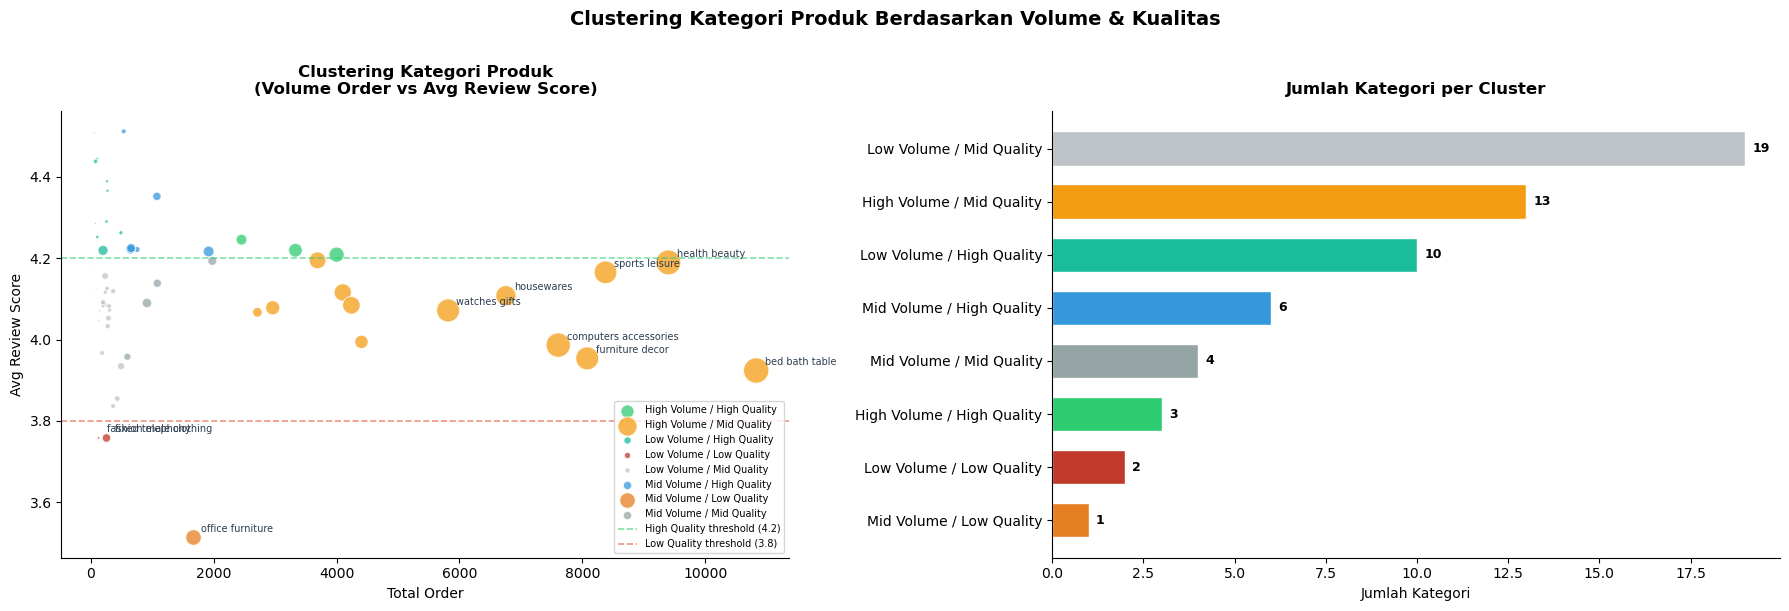

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Warna per cluster
cluster_colors = {
    'High Volume / High Quality'  : '#2ecc71',
    'High Volume / Mid Quality'   : '#f39c12',
    'High Volume / Low Quality'   : '#e74c3c',
    'Mid Volume / High Quality'   : '#3498db',
    'Mid Volume / Mid Quality'    : '#95a5a6',
    'Mid Volume / Low Quality'    : '#e67e22',
    'Low Volume / High Quality'   : '#1abc9c',
    'Low Volume / Mid Quality'    : '#bdc3c7',
    'Low Volume / Low Quality'    : '#c0392b',
}

# --- Scatter: Volume vs Score per cluster ---
for cluster_name, group in category_perf.groupby('cluster'):
    color = cluster_colors.get(cluster_name, '#888888')
    axes[0].scatter(
        group['total_orders'], group['avg_score'],
        s=group['total_revenue'] / 5000,
        color=color, alpha=0.75, edgecolors='white', linewidth=0.8,
        label=cluster_name
    )
    # Label untuk outlier penting
    for _, row in group.iterrows():
        if row['total_orders'] > 5000 or row['avg_score'] < 3.8:
            axes[0].annotate(
                row['product_category_name_english'].replace('_', ' '),
                xy=(row['total_orders'], row['avg_score']),
                xytext=(6, 4), textcoords='offset points',
                fontsize=7, color='#2c3e50'
            )

axes[0].axhline(y=4.2, color='#2ecc71', linestyle='--', linewidth=1.2, alpha=0.6, label='High Quality threshold (4.2)')
axes[0].axhline(y=3.8, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.6, label='Low Quality threshold (3.8)')
axes[0].set_title('Clustering Kategori Produk\n(Volume Order vs Avg Review Score)', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Total Order', fontsize=10)
axes[0].set_ylabel('Avg Review Score', fontsize=10)
axes[0].legend(fontsize=7, loc='lower right', ncol=1)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Bar: Jumlah Kategori per Cluster ---
cluster_count = category_perf['cluster'].value_counts().sort_values(ascending=True)
bar_colors_c  = [cluster_colors.get(c, '#888') for c in cluster_count.index]
axes[1].barh(cluster_count.index, cluster_count.values, color=bar_colors_c, edgecolor='white', height=0.65)
for i, val in enumerate(cluster_count.values):
    axes[1].text(val + 0.2, i, str(val), va='center', fontsize=9, fontweight='bold')
axes[1].set_title('Jumlah Kategori per Cluster', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Jumlah Kategori', fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Clustering Kategori Produk Berdasarkan Volume & Kualitas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insight Clustering:**
- Clustering dilakukan dengan **binning dua dimensi**: volume order (Low/Mid/High) dan kualitas review (Low/Mid/High Quality)
- Kategori **High Volume / High Quality** adalah aset utama bisnis — pertahankan kualitas dan tingkatkan promosi
- Kategori **High Volume / Low Quality** adalah yang paling kritis — volume besar tapi kepuasan rendah berdampak langsung pada reputasi platform
- Kategori **Low Volume / Low Quality** bisa dipertimbangkan untuk dievaluasi ulang atau dihapus dari platform jika tidak ada perbaikan

In [36]:
# Merge semua dataset jadi main_data
main_data = (
    orders_clean
    .merge(payment_agg, on='order_id', how='left')
    .merge(order_items_df[['order_id', 'product_id', 'price', 'freight_value']], on='order_id', how='left')
    .merge(products_df[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(category_trans_df, on='product_category_name', how='left')
    .merge(reviews_per_order, on='order_id', how='left')
)

main_data.to_csv('main_data.csv', index=False)
print(f"✅ main_data.csv berhasil disimpan!")
print(f"   Total baris : {len(main_data):,}")
print(f"   Total kolom : {len(main_data.columns)}")

✅ main_data.csv berhasil disimpan!
   Total baris : 110,197
   Total kolom : 18


In [37]:
main_data.to_csv('main_data.csv', index=False)
print(f"main_data.csv berhasil disimpan!")
print(f"   Total baris : {len(main_data):,}")
print(f"   Total kolom : {len(main_data.columns)}")

main_data.csv berhasil disimpan!
   Total baris : 110,197
   Total kolom : 18


## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Revenue bulanan tahun 2018 berfluktuasi dengan puncak tertinggi pada bulan **April 2018**, kemudian mengalami tren penurunan bertahap dari Juni hingga akhir tahun. Pola ini mengindikasikan adanya **musim penjualan tinggi di awal hingga pertengahan tahun** (Januari–April) dan perlambatan di paruh kedua. Secara keseluruhan, revenue 2018 lebih tinggi dibandingkan periode yang sama di tahun 2017, yang menunjukkan pertumbuhan bisnis yang positif.
- **Conclusion pertanyaan 2:** Terdapat **13 kategori produk** yang memiliki rata-rata review score di bawah 4.0 pada tahun 2017. Kategori paling kritis adalah **office_furniture** (score 3.57) dengan volume 785 order, diikuti **construction_tools_lights** (3.61) dan **fashion_male_clothing** (3.61). Kategori-kategori ini menunjukkan ketidakpuasan pelanggan yang perlu segera ditangani agar tidak berdampak pada retensi pelanggan.

**Rekomendasi Action Item:**
- Optimalkan kampanye promosi dan stok produk pada periode **Januari–Mei** saat tren revenue sedang naik, serta buat program diskon atau flash sale khusus di **Juni–Agustus** untuk menahan penurunan musiman
- Prioritaskan perbaikan kualitas pada kategori **office_furniture** dan **fashion_male_clothing** — fokus pada akurasi deskripsi produk, standardisasi foto, dan kualitas pengemasan agar ekspektasi pelanggan terpenuhi
- Terapkan **program seller quality control** untuk 13 kategori bermasalah: wajibkan standar minimum listing produk dan berikan insentif kepada seller yang mampu mempertahankan rating di atas 4.0 secara konsisten